This changes the sparsity of interactions and tries to see if there is a correlation between the co-abundance interaction sparsity and the actual interaction sparsity. 

TODO -- gotta do this with more formal procedures for pseudo pvals or something
Note -- adding random or trait matching noise requires longer times for equilibrium (the latter more than the former)
So far, random environmental noise appears to reduce the proportion of realized links in a cooccurrence network, particularly at intermediate cutoffs and high interaction densities. Trait matching noise increases the proportion of realized links, presumably (as will be tested later)because the species that share environmental preferences will have stronger signals of cooccurrence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx

import metaCommunityMx
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(metrics_and_plotting)
reload(run_cooccurrence)

<module 'run_cooccurrence' from '/Users/claireevensen/CooccurCollab/TheoryCoOccur/run_cooccurrence.py'>

In [ ]:
# for random matrix
interactFactor = 1/10
nSpec = 100
pPositive = 0.4 

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

In [ ]:
# zeroMx = np.zeros(shape = (nSpec, nSpec))
pInteractL = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] 
cutoffL = [0.05, 0.1, 0.15, 0.2]

totalCoocEdge = np.zeros(shape = (len(pInteractL), len(cutoffL)))
totalInteractEdge = np.zeros(shape = (len(pInteractL), len(cutoffL)))

for i in range(len(pInteractL)):
    pInteract = pInteractL[i]
    print(pInteract)
    for j in range(len(cutoffL)):
        cutoff = cutoffL[j]
        if pInteract in [0, 0.1, 0.2, 0.8, 1] and cutoff == 0.15:
            plotNet = True
        else:
            plotNet = False

        # make new interaction mx with different proportion of edges
        randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

        # run sim to get coocurrence network
        network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, plotNetworks = plotNet)
        G_rand_inter = nx.from_numpy_array(randMx != 0)

        # save stats
        totalCoocEdge[i,j] = sum(sum(network_rand != 0))
        totalInteractEdge[i,j] = sum(sum(randMx != 0))

pCoocL = totalCoocEdge / (nSpec**2-nSpec) 
pInteractL = totalInteractEdge / (nSpec**2-nSpec) 
        
print(np.round(pCoocL, 2))
print(np.round(pInteractL, 2))

In [51]:
pCoocL = [totalCoocEdge[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge))]
pInteractL = [totalInteractEdge[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge))]

print(np.round(totalCoocEdge))
print(totalInteractEdge)

print(np.round(pCoocL, 2))
print((np.round(pInteractL, 2)))


[[2806.  304.   10.    0.]
 [3152.  742.  102.   20.]
 [3976. 1150.  240.   60.]
 [4440. 1560.  480.  100.]
 [4868. 1872.  650.  164.]
 [5330. 2362.  736.  148.]
 [5736. 2468.  812.  250.]
 [5870. 2660.  818.  288.]
 [5802. 2842.  976.  260.]
 [5952. 2922. 1088.  346.]
 [6026. 3184. 1296.  318.]]
[[   0.    0.    0.    0.]
 [ 978.  996.  940.  985.]
 [1955. 1945. 2004. 1950.]
 [2914. 2953. 2977. 2914.]
 [3972. 3946. 3867. 3909.]
 [4965. 4929. 4974. 4924.]
 [5922. 5893. 5812. 5907.]
 [6973. 6919. 6966. 6875.]
 [7862. 7872. 7891. 7936.]
 [8857. 8883. 8875. 8923.]
 [9900. 9900. 9900. 9900.]]
[[0.28 0.03 0.   0.  ]
 [0.32 0.07 0.01 0.  ]
 [0.4  0.12 0.02 0.01]
 [0.45 0.16 0.05 0.01]
 [0.49 0.19 0.07 0.02]
 [0.54 0.24 0.07 0.01]
 [0.58 0.25 0.08 0.03]
 [0.59 0.27 0.08 0.03]
 [0.59 0.29 0.1  0.03]
 [0.6  0.3  0.11 0.03]
 [0.61 0.32 0.13 0.03]]
[[0.   0.   0.   0.  ]
 [0.1  0.1  0.09 0.1 ]
 [0.2  0.2  0.2  0.2 ]
 [0.29 0.3  0.3  0.29]
 [0.4  0.4  0.39 0.39]
 [0.5  0.5  0.5  0.5 ]
 [0.6  0.6  

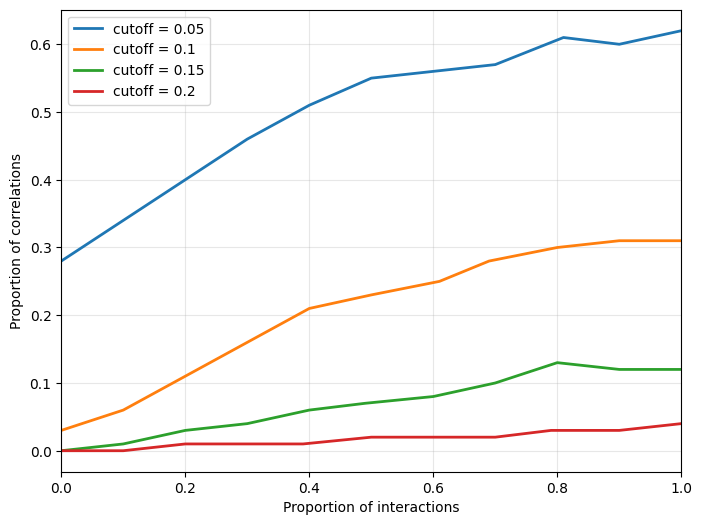

In [65]:
# plot cluster correctness versus number of links between modules
pCoocL = np.round(pCoocL, 2)
pInteractL =(np.round(pInteractL, 2))

plt.figure(figsize=(8, 6))

for i in range(len(cutoffL)):
    plt.plot(pInteractL[:,i], pCoocL[:,i], lw=2, label = f"cutoff = {cutoffL[i]}")
plt.xlim(0, 1)
# plt.hlines(rand_prop_correct, xmin = 0, xmax = maxEBetween, color='gray', lw=1, linestyle='--')
plt.xlabel('Proportion of interactions')
plt.ylabel('Proportion of correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Random Environment Noise
pInteractL = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] 
cutoffL = [0.05, 0.1, 0.15, 0.2]

totalCoocEdge_re = np.zeros(shape = (len(pInteractL), len(cutoffL)))
totalInteractEdge_re = np.zeros(shape = (len(pInteractL), len(cutoffL)))

for i in range(len(pInteractL)):
    pInteract = pInteractL[i]
    print(pInteract)
    for j in range(len(cutoffL)):
        cutoff = cutoffL[j]
        if pInteract in [0, 0.1, 0.2, 0.8, 1] and cutoff == 0.15:
            plotNet = True
        else:
            plotNet = False

        # make new interaction mx with different proportion of edges
        randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

        # run sim to get coocurrence network
        network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network_randenv(interactionMx = randMx, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, plotNetworks = plotNet, noise = 0.6)
        G_rand_inter = nx.from_numpy_array(randMx != 0)

        # save stats
        totalCoocEdge_re[i,j] = sum(sum(network_rand != 0))
        totalInteractEdge_re[i,j] = sum(sum(randMx != 0))

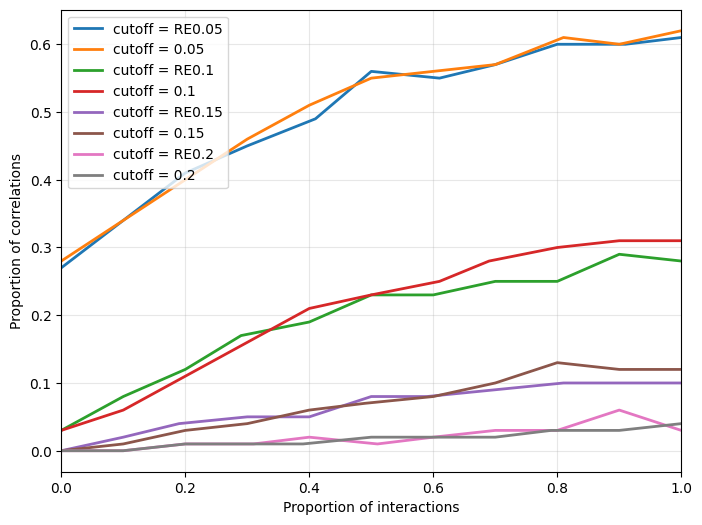

In [66]:
# plot proportion of realized edges
pCoocL_re = [totalCoocEdge_re[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge_re))]
pInteractL_re = [totalInteractEdge_re[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge_re))]

pCoocL_re = np.round(pCoocL_re, 2)
pInteractL_re =(np.round(pInteractL_re, 2))

plt.figure(figsize=(8, 6))
for i in range(len(cutoffL)):
    plt.plot(pInteractL_re[:,i], pCoocL_re[:,i], lw=2, label = f"cutoff = RE{cutoffL[i]}")
    plt.plot(pInteractL[:,i], pCoocL[:,i], lw=2, label = f"cutoff = {cutoffL[i]}")
plt.xlim(0, 1)
# plt.hlines(rand_prop_correct, xmin = 0, xmax = maxEBetween, color='gray', lw=1, linestyle='--')
plt.xlabel('Proportion of interactions')
plt.ylabel('Proportion of correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Trait Matching Environment Noise
traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

pInteractL = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] 
cutoffL = [0.05, 0.1, 0.15, 0.2]

totalCoocEdge_tm = np.zeros(shape = (len(pInteractL), len(cutoffL)))
totalInteractEdge_tm = np.zeros(shape = (len(pInteractL), len(cutoffL)))

for i in range(len(pInteractL)):
    pInteract = pInteractL[i]
    print(pInteract)
    for j in range(len(cutoffL)):
        cutoff = cutoffL[j]
        if pInteract in [0, 0.1, 0.2, 0.8, 1] and cutoff == 0.15:
            plotNet = True
        else:
            plotNet = False

        # make new interaction mx with different proportion of edges
        randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

        # run sim to get coocurrence network
        network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, plotNetworks = plotNet, noise = 0.6)
        G_rand_inter = nx.from_numpy_array(randMx != 0)

        # save stats
        totalCoocEdge_tm[i,j] = sum(sum(network_rand != 0))
        totalInteractEdge_tm[i,j] = sum(sum(randMx != 0))

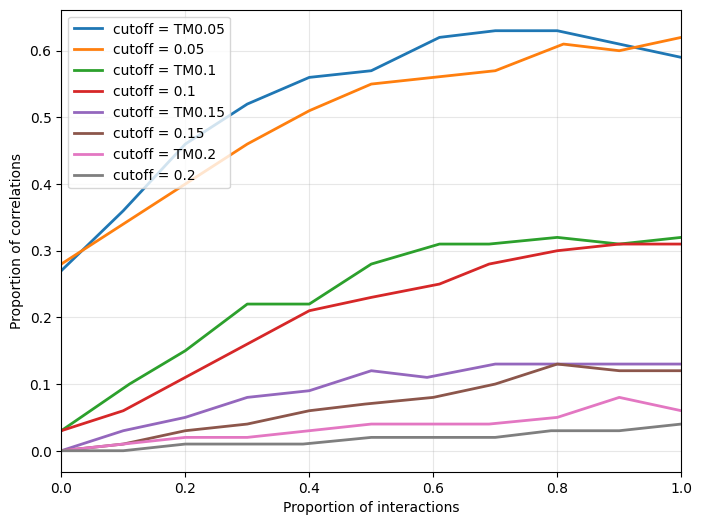

In [67]:
# plot proportion of realized edges
pCoocL_tm = [totalCoocEdge_tm[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge_tm))]
pInteractL_tm = [totalInteractEdge_tm[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge_tm))]

pCoocL_tm = np.round(pCoocL_tm, 2)
pInteractL_tm =(np.round(pInteractL_tm, 2))

plt.figure(figsize=(8, 6))
for i in range(len(cutoffL)):
    plt.plot(pInteractL_tm[:,i], pCoocL_tm[:,i], lw=2, label = f"cutoff = TM{cutoffL[i]}")
    plt.plot(pInteractL[:,i], pCoocL[:,i], lw=2, label = f"cutoff = {cutoffL[i]}")
plt.xlim(0, 1)
# plt.hlines(rand_prop_correct, xmin = 0, xmax = maxEBetween, color='gray', lw=1, linestyle='--')
plt.xlabel('Proportion of interactions')
plt.ylabel('Proportion of correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

0.09562182845442946
0.23704605155429048
0.25066180997919607
0.1713014721786339
0.7253123500314586
0.6100439591944778
0.09398498217506945
0.6467673967863743
0.1311457476989828
0.30510540292059274
0.09242302167405303
0.8688425062714465
0.4343728453057696
0.8831233023995737
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
1.0
0.012965273898147944
0.356160370193189
0.3755907135190558
0.7493007414051621
0.33405349508110904
0.5320713415372024
0.4335167581144671
0.7689281666978914
0.468285927135212
0.04607621546938734
0.05914807651611653
0.022734743746257613
0.10307346083573576
0.7994474363310846
0.24926774402096985
0.6359473186529137
0.7308443436642705
0.1288897272383296
0.33657182190514956
0.537001698586533
0.4630827566216109
0.7435112818827854
0.4844505720947113
0.22456128314228652
0.39734950333786756
0.21059716437064946
0.384498672039025
0.5949386199489342
0.5740872308979844
0.8496529118

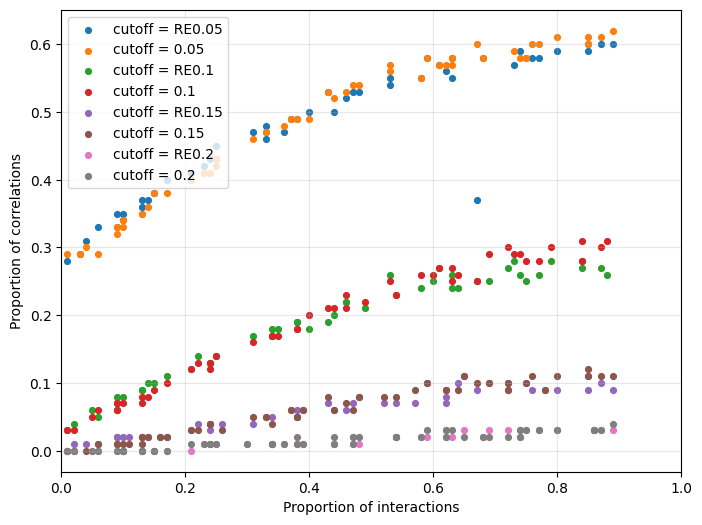

In [81]:
# Random Environment Noise vs Constant Environment

# for random matrix
interactFactor = 1/10
interactStren = alpha * interactFactor
nSpec = 100
pPositive = 0.4 

# parms for GLV sim
alpha = 0.05 
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500

pInteract_list = np.random.uniform(low = 0, high = 1, size = 50)
cutoffs = [0.05, 0.1, 0.15, 0.2]

totalCoocEdge = np.zeros(shape = (len(pInteract_list), len(cutoffs)))
totalInteractEdge = np.zeros(shape = (len(pInteract_list), len(cutoffs)))

totalCoocEdge_re = np.zeros(shape = (len(pInteract_list), len(cutoffs)))
totalInteractEdge_re = np.zeros(shape = (len(pInteract_list), len(cutoffs)))

for i in range(len(pInteract_list)):
    pInteract = pInteract_list[i]
    print(pInteract)
    for j in range(len(cutoffs)):
        cutoff = cutoffs[j]

        #For each trial, generate new list of birthrates
        b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))
        
        # make new interaction mx with different proportion of edges
        randMx_const = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
        randMx_re = randMx_const.copy()
        #save stats
        totalInteractEdge[i,j] = sum(sum(randMx_const != 0))
        totalInteractEdge_re[i,j] = sum(sum(randMx_re != 0))
        # run sim to get coocurrence network

        network_re, G_re_coocc = run_cooccurrence.get_coocc_network_randenv(interactionMx = randMx_re, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, noise = 0.6)
        network_const, G_const_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx_const, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b)

        # save stats
        totalCoocEdge[i,j] = sum(sum(network_const != 0))
        totalCoocEdge_re[i,j] = sum(sum(network_re != 0))
        


# plot proportion of realized edges
pCoocL_re = [totalCoocEdge_re[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge_re))]
pInteractL_re = [totalInteractEdge_re[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge_re))]

pCoocL_re = np.round(pCoocL_re, 2)
pInteractL_re = np.round(pInteractL_re, 2)

pCoocL = [totalCoocEdge[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge))]
pInteractL = [totalInteractEdge[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge))]

pCoocL = np.round(pCoocL, 2)
pInteractL = np.round(pInteractL, 2)


plt.figure(figsize=(8, 6))
for i in range(len(cutoffs)):
    plt.scatter(pInteractL_re[:,i], pCoocL_re[:,i], lw=2, label = f"cutoff = RE{cutoffL[i]}", s=10)
    plt.scatter(pInteractL[:,i], pCoocL[:,i], lw=2, label = f"cutoff = {cutoffL[i]}", s=10)
plt.xlim(0, 1)
# plt.hlines(rand_prop_correct, xmin = 0, xmax = maxEBetween, color='gray', lw=1, linestyle='--')
plt.xlabel('Proportion of interactions')
plt.ylabel('Proportion of correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

0
Did not reach equilibrium; run with higher tmax
2.0
Did not reach equilibrium; run with higher tmax
3.0
Did not reach equilibrium; run with higher tmax
0.0
1
2
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
0.0
Did not reach equilibrium; run with higher tmax
5.0
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
0.0
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
2.0
3
Did not reach equilibrium; run with higher tmax
1.0
4
5
6
7
8
9
10
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
1.0
11
12
Did not reach equilibrium; run with higher tmax
1.0
Did not reach equilibrium; run with higher tmax
0.0
Did not reach equilibrium; run with

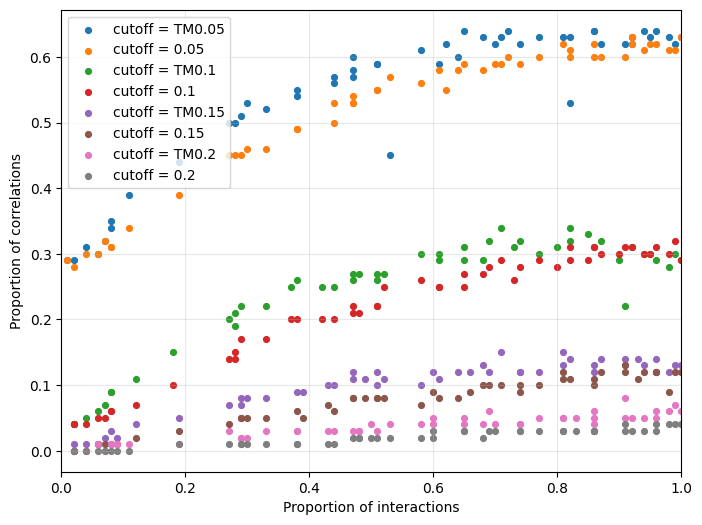

In [80]:
# Trait Matching Environment Noise vs Constant Environment

# for random matrix
interactFactor = 1/10
interactStren = alpha * interactFactor
nSpec = 100
pPositive = 0.4 

# parms for GLV sim
alpha = 0.05 
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500

pInteract_list = np.random.uniform(low = 0, high = 1, size = 50)
cutoffs = [0.05, 0.1, 0.15, 0.2]

totalCoocEdge = np.zeros(shape = (len(pInteract_list), len(cutoffs)))
totalInteractEdge = np.zeros(shape = (len(pInteract_list), len(cutoffs)))

totalCoocEdge_tm = np.zeros(shape = (len(pInteract_list), len(cutoffs)))
totalInteractEdge_tm = np.zeros(shape = (len(pInteract_list), len(cutoffs)))

for i in range(len(pInteract_list)):
    pInteract = pInteract_list[i]
    print(i)
    for j in range(len(cutoffs)):
        cutoff = cutoffs[j]
        #For each trial, pick a new birthrate and trait vector
        b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))
        traits = np.random.uniform(low = 0, high = 1, size = (nSpec))
        # make new interaction mx with different proportion of edges
        randMx_const = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
        randMx_tm = randMx_const.copy()
        #save stats
        totalInteractEdge[i,j] = sum(sum(randMx_const != 0))
        totalInteractEdge_tm[i,j] = sum(sum(randMx_tm != 0))
        # run sim to get coocurrence network

        network_tm, G_tm_coocc = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_tm, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, plotNetworks = plotNet, noise = 0.6)
        network_const, G_const_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx_const, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b)

        # save stats
        totalCoocEdge[i,j] = sum(sum(network_const != 0))
        totalCoocEdge_tm[i,j] = sum(sum(network_tm != 0))
        


# plot proportion of realized edges
pCoocL_tm = [totalCoocEdge_tm[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge_tm))]
pInteractL_tm = [totalInteractEdge_tm[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge_tm))]

pCoocL_tm = np.round(pCoocL_tm, 2)
pInteractL_tm = np.round(pInteractL_tm, 2)

pCoocL = [totalCoocEdge[i] / (nSpec**2-nSpec) for i in range(len(totalCoocEdge))]
pInteractL = [totalInteractEdge[i] / (nSpec**2-nSpec) for i in range(len(totalInteractEdge))]

pCoocL = np.round(pCoocL, 2)
pInteractL = np.round(pInteractL, 2)


plt.figure(figsize=(8, 6))
for i in range(len(cutoffs)):
    plt.scatter(pInteractL_tm[:,i], pCoocL_tm[:,i], lw=2, label = f"cutoff = TM{cutoffL[i]}", s=10)
    plt.scatter(pInteractL[:,i], pCoocL[:,i], lw=2, label = f"cutoff = {cutoffL[i]}", s=10)
plt.xlim(0, 1)
# plt.hlines(rand_prop_correct, xmin = 0, xmax = maxEBetween, color='gray', lw=1, linestyle='--')
plt.xlabel('Proportion of interactions')
plt.ylabel('Proportion of correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
a = np.array([1, 2, 3])
b = a.copy()
print(b)

[1 2 3]
